# 05 — Tap–Motion Coupling (P2)

## The idea

A tap is a physical impact. Newton's third law says the finger striking the glass pushes
the handset away, so every `touchstart` should produce a small impulse in the
accelerometer. If that impulse is measurable, its **shape** encodes things no timing
feature can reach: how hard the person strikes, how firmly they grip, whether the phone
is held in the hand or resting on a surface.

This is the first thing in the project that couples two sensor streams rather than
treating each modality separately, which is why it gets its own notebook.

## What this notebook establishes

The impulse is real and it is not subtle. Averaged over ~1,400 taps, acceleration is flat
before the tap and jumps sharply in the sample immediately after, decaying over roughly
250ms. A control built by shifting each tap time by a random 2–10 seconds — same session,
same motion statistics, alignment destroyed — stays flat throughout.

The per-participant shapes then differ in a physically interpretable way: some strike hard
and the handset rings on for 250ms, some strike hard and it damps within 75ms, one barely
registers at all. That is tap force crossed with grip firmness.

## What it does not establish

Four things qualify the result, and none of them is cosmetic:

1. **Roughly half of taps are unusable** because they fall in motion-dropout stretches.
2. **The amplitude features are pace-loaded** (r ≈ +0.8 with session duration), so they
   partly re-measure what the timing features already say.
3. **20 Hz sampling** gives one motion sample per 50ms, so the impulse is described by
   two or three points and its true transient is aliased.
4. **The device confound bites harder here than anywhere else in the project**, because
   accelerometer sensitivity, handset mass and case damping scale the amplitude directly.

Sections 8–10 measure each of these rather than mentioning them and moving on.

## Reading order

| Section | What it answers |
|---|---|
| 3 | What can 20 Hz actually resolve? |
| 4 | How often is motion even available around a tap? |
| 5 | Is there an impulse at all? (event-related average vs shifted control) |
| 6 | What does each person's impulse look like? |
| 7 | Do the impulse features separate people? |
| 8 | Is it just measuring pace again? |
| 9 | Is it just measuring the handset? |
| 10 | Which axis carries it, and does the ratio survive where amplitude doesn't? |


## 1. Setup and load

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

RAW_EVENTS_PARQUET = "../../data/processed/raw_events.parquet"
RAW_EVENTS_CSV = "../../data/processed/raw_events.csv"
if Path(RAW_EVENTS_PARQUET).exists():
    raw_all = pd.read_parquet(RAW_EVENTS_PARQUET); _src = RAW_EVENTS_PARQUET
else:
    raw_all = pd.read_csv(RAW_EVENTS_CSV, low_memory=False); _src = RAW_EVENTS_CSV

raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()

# Mobile only — desktop has no accelerometer, so the question does not exist there.
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

TAP_KIND = 'touchstart'
MOTION_KIND = 'devicemotion'
ACCEL_COLS = ['payload_ax', 'payload_ay', 'payload_az']   # linear accel, gravity removed
AXIS_NAMES = {'payload_ax': 'x (across screen)',
              'payload_ay': 'y (up screen)',
              'payload_az': 'z (perpendicular to screen)'}

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      n_taps=('kind', lambda s: (s == TAP_KIND).sum()),
                      n_motion=('kind', lambda s: (s == MOTION_KIND).sum()),
                      started=('timestampIso', 'min'))
                 .reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['observed_session_number'] = session_index.groupby('participantId').cumcount() + 1

# Participants ordered slowest -> fastest, matching notebook 04 so colours agree.
_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANT_ORDER = _p_dur.index.astype(str).tolist()
PARTICIPANT_COLORS = {p: plt.get_cmap('turbo')((i + 0.5) / max(1, len(PARTICIPANT_ORDER)))
                      for i, p in enumerate(PARTICIPANT_ORDER)}
def pcolor(p): return PARTICIPANT_COLORS.get(str(p), '0.5')

print(f"Loaded {_src}")
print(f"mobile: {len(raw):,} events | {raw['sessionId'].nunique()} sessions | "
      f"{raw['participantId'].nunique()} participants")
print(f"taps: {(raw['kind'] == TAP_KIND).sum():,} | motion samples: {(raw['kind'] == MOTION_KIND).sum():,}")
session_index[['participantId', 'observed_session_number', 'duration_s', 'n_taps', 'n_motion']]

Loaded ../../data/processed/raw_events.parquet
mobile: 227,356 events | 13 sessions | 6 participants
taps: 2,244 | motion samples: 66,964


,participantId,observed_session_number,duration_s,n_taps,n_motion
0,p3M6E7Z,1,955.911,194,14353
1,p3YDMHG,1,316.604,106,4754
2,p3YDMHG,2,399.510,126,6044
3,pA6XL23,1,376.487,205,5432
4,pA6XL23,2,259.676,202,3855
5,pG5G4MS,1,143.617,116,1835
6,pG5G4MS,2,131.901,116,1840
7,pG5G4MS,3,141.304,120,1951
8,pG5G4MS,4,151.457,105,2186
9,pH3S4X4,1,680.796,258,8791


## 2. What 20 Hz can actually resolve

Before any analysis, the physical limit. `devicemotion` is throttled to a fixed interval,
so the question is what fraction of a tap transient survives sampling at that rate.

A finger impact on glass is a millisecond-scale event that excites handset resonances in
the tens to hundreds of Hz. At the observed rate the Nyquist limit sits far below that,
so **the sharp transient is aliased and unrecoverable** — what remains measurable is the
lower-frequency envelope: the handset's bulk displacement and ring-down, which is still
physically meaningful because it is governed by how the phone is held.

That limit is the reason Section 7's latency feature underperforms: peak latency can only
be resolved to about one sample, so most of its variation is quantisation rather than
behaviour.

In [2]:
_rates = []
for sid, g in raw.groupby('sessionId'):
    t = np.sort(g.loc[g['kind'] == MOTION_KIND, 'tRelMs'].to_numpy(float))
    if len(t) < 20:
        continue
    d = np.diff(t); d = d[(d > 0) & (d < 1000)]
    _rates.append({'sessionId': sid, 'participantId': g['participantId'].iloc[0],
                   'n_samples': len(t), 'median_dt_ms': float(np.median(d)),
                   'hz': 1000.0 / float(np.median(d)), 'p95_dt_ms': float(np.percentile(d, 95))})
motion_rate = pd.DataFrame(_rates)

SAMPLE_DT_MS = float(motion_rate['median_dt_ms'].median())
SAMPLE_HZ = 1000.0 / SAMPLE_DT_MS
NYQUIST_HZ = SAMPLE_HZ / 2.0

print(f"Motion sampling: {SAMPLE_HZ:.1f} Hz (one sample every {SAMPLE_DT_MS:.0f} ms), "
      f"Nyquist {NYQUIST_HZ:.1f} Hz")
print(f"Consistent across sessions: {motion_rate['hz'].min():.1f}-{motion_rate['hz'].max():.1f} Hz\n")
print(f"-> a 300 ms post-tap response is described by ~{300 / SAMPLE_DT_MS:.0f} samples")
print(f"-> peak-latency resolution is no better than +/-{SAMPLE_DT_MS / 2:.0f} ms")
print(f"-> anything above {NYQUIST_HZ:.0f} Hz is aliased; treat only the envelope as real")
motion_rate.round(2)

Motion sampling: 20.0 Hz (one sample every 50 ms), Nyquist 10.0 Hz
Consistent across sessions: 20.0-20.0 Hz

-> a 300 ms post-tap response is described by ~6 samples
-> peak-latency resolution is no better than +/-25 ms
-> anything above 10 Hz is aliased; treat only the envelope as real


,sessionId,participantId,n_samples,median_dt_ms,hz,p95_dt_ms
0,10841bbef7224a8ebe1bbf700c042e58,pH3S4X4,8791,50.0,20.0,67.0
1,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,5432,50.0,20.0,67.0
2,407ab28165b243dfaa35b57079af7ecd,pA6XL23,3855,50.0,20.0,68.7
3,4efd22c4dc0440d4adf14013e8d83cf0,p3YDMHG,4754,50.0,20.0,67.0
4,7b3e1071217a4000818d17bff3756a39,pG5G4MS,1951,50.0,20.0,69.0
5,8102752ec8f7482a8fdd4971669fe3b7,p3YDMHG,6044,50.0,20.0,67.0
6,83b1d10e06d9416c98ea553bff035c91,pG5G4MS,2186,50.0,20.0,67.0
7,9187000b80d44d96a937a8d8b887e4f7,pH3S4X4,4570,50.0,20.0,68.0
8,a478f645db5147abbefc6f59a277ee56,pZMC82M,5635,50.0,20.0,70.0
9,b1700a0f31cb4f16ba0a035b7ece41a2,pG5G4MS,1835,50.0,20.0,69.0


## 3. Motion availability around taps

A tap is only usable if motion was being recorded either side of it. Motion drops out for
long stretches, so this sets a hard ceiling on how often the feature can contribute at
all — and therefore why it can never carry a fixed fusion weight.

A tap is counted usable when there are at least two motion samples in the pre-window
(needed for a baseline and a noise estimate) and three in the post-window.

In [3]:
PRE_MS, POST_MS = 300.0, 500.0     # epoch around each tap
BASELINE_END_MS = -50.0            # pre-tap baseline ends here, before any anticipation
RESPONSE_MS = (0.0, 300.0)         # where the impulse is expected
TAIL_MS = (200.0, 450.0)           # ring-down region
MIN_PRE_SAMPLES, MIN_POST_SAMPLES = 2, 3


def motion_arrays(sess):
    dm = sess.loc[sess['kind'] == MOTION_KIND].sort_values('tRelMs')
    if len(dm) < 20:
        return None
    t = dm['tRelMs'].to_numpy(float)
    comps = {c: pd.to_numeric(dm[c], errors='coerce').to_numpy(float) for c in ACCEL_COLS}
    mag = np.sqrt(sum(v ** 2 for v in comps.values()))
    return {'t': t, 'comps': comps, 'mag': mag}


def epoch_at(arrs, t0, signal=None):
    '''Baseline-corrected epoch around t0. Baseline removal is what strips out posture
    and slow drift, leaving only the change locked to the event.'''
    t = arrs['t']
    v = arrs['mag'] if signal is None else signal
    i0, i1 = np.searchsorted(t, t0 - PRE_MS), np.searchsorted(t, t0 + POST_MS)
    off, seg = t[i0:i1] - t0, v[i0:i1]
    pre = off < BASELINE_END_MS
    post = (off >= RESPONSE_MS[0]) & (off <= RESPONSE_MS[1])
    if pre.sum() < MIN_PRE_SAMPLES or post.sum() < MIN_POST_SAMPLES:
        return None
    return off, seg - seg[pre].mean(), seg[pre].std()


_cov = []
for sid, sess in raw.groupby('sessionId'):
    arrs = motion_arrays(sess)
    taps = np.sort(sess.loc[sess['kind'] == TAP_KIND, 'tRelMs'].to_numpy(float))
    usable = 0
    if arrs is not None:
        usable = sum(epoch_at(arrs, tp) is not None for tp in taps)
    _cov.append({'participantId': sess['participantId'].iloc[0], 'sessionId': sid,
                 'n_taps': len(taps), 'usable': usable,
                 'coverage': usable / len(taps) if len(taps) else np.nan})
tap_coverage = pd.DataFrame(_cov)

print(f"Usable taps: {tap_coverage['usable'].sum():,} of {tap_coverage['n_taps'].sum():,} "
      f"({tap_coverage['usable'].sum() / tap_coverage['n_taps'].sum():.1%})")
print("The remainder fall inside motion-dropout stretches.\n")
print(tap_coverage.groupby('participantId')[['n_taps', 'usable', 'coverage']]
      .agg({'n_taps': 'sum', 'usable': 'sum', 'coverage': 'mean'}).round(3).to_string())

Usable taps: 1,247 of 2,244 (55.6%)
The remainder fall inside motion-dropout stretches.

               n_taps  usable  coverage
participantId                          
p3M6E7Z           194     139     0.716
p3YDMHG           232     163     0.707
pA6XL23           407     163     0.401
pG5G4MS           457     281     0.616
pH3S4X4           672     299     0.443
pZMC82M           282     202     0.716


## 4. Is there an impulse at all?

The existence test, and it needs a control that is genuinely hard to pass.

Averaging acceleration around taps will show *something* no matter what, because taps
happen when the person is active and activity means motion. So the control shifts each
tap time by a random 2–10 seconds within the same session. That preserves the session,
the participant, the handset, the general activity level and the motion statistics —
everything except the alignment to the tap itself. If the impulse is real, the shifted
average is flat.

Every epoch is baseline-corrected against its own pre-tap window, so posture and slow
drift are removed before averaging.

In [4]:
BIN_MS = 50.0
CONTROL_SHIFT_MS = (2000.0, 10000.0)
RANDOM_SEED = 7

_edges = np.arange(-PRE_MS, POST_MS + BIN_MS, BIN_MS)
BIN_MIDS = _edges[:-1] + BIN_MS / 2.0


def binned_epochs(arrs, event_times):
    '''Stack of baseline-corrected epochs, resampled onto a common time grid so that
    epochs with different sample phases can be averaged.'''
    out = []
    for t0 in event_times:
        ep = epoch_at(arrs, t0)
        if ep is None:
            continue
        off, v, _ = ep
        idx = np.digitize(off, _edges) - 1
        row = np.full(len(BIN_MIDS), np.nan)
        for b in range(len(BIN_MIDS)):
            m = idx == b
            if m.any():
                row[b] = v[m].mean()
        out.append(row)
    return np.array(out) if out else np.empty((0, len(BIN_MIDS)))


def build_event_related(raw_df, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    real, ctrl, meta = [], [], []
    for sid, sess in raw_df.groupby('sessionId'):
        arrs = motion_arrays(sess)
        if arrs is None:
            continue
        taps = np.sort(sess.loc[sess['kind'] == TAP_KIND, 'tRelMs'].to_numpy(float))
        if len(taps) < 20:
            continue
        shifted = taps + rng.uniform(*CONTROL_SHIFT_MS, len(taps))
        R, C = binned_epochs(arrs, taps), binned_epochs(arrs, shifted)
        if len(R) == 0:
            continue
        real.append(R); ctrl.append(C)
        meta.append(pd.DataFrame({'participantId': sess['participantId'].iloc[0],
                                  'sessionId': sid}, index=range(len(R))))
    return (np.vstack(real), np.vstack([c for c in ctrl if len(c)]),
            pd.concat(meta, ignore_index=True))


era_real, era_ctrl, era_meta = build_event_related(raw)
print(f"epochs — real: {len(era_real):,}   time-shifted control: {len(era_ctrl):,}")

_peak_bin = int(np.nanargmax(np.nanmean(era_real, axis=0)))
_a = era_real[:, _peak_bin]; _a = _a[np.isfinite(_a)]
_b = era_ctrl[:, _peak_bin]; _b = _b[np.isfinite(_b)]
_t, _p = stats.ttest_ind(_a, _b, equal_var=False)
_d = (_a.mean() - _b.mean()) / np.sqrt((_a.std(ddof=1) ** 2 + _b.std(ddof=1) ** 2) / 2)

print(f"\npeak bin {BIN_MIDS[_peak_bin]:+.0f} ms")
print(f"  real    {_a.mean():+.4f}  (n={len(_a):,})")
print(f"  control {_b.mean():+.4f}  (n={len(_b):,})")
print(f"  Welch t={_t:.1f}, p={_p:.2e}, Cohen d={_d:.3f}")
print("\nNote: epochs from one session are not independent, so the p-value is far more")
print("confident than the design warrants. The control comparison is the real evidence.")

epochs — real: 1,247   time-shifted control: 1,523

peak bin +25 ms
  real    +0.3377  (n=1,202)
  control -0.0067  (n=1,327)
  Welch t=18.9, p=4.16e-74, Cohen d=0.760

Note: epochs from one session are not independent, so the p-value is far more
confident than the design warrants. The control comparison is the real evidence.


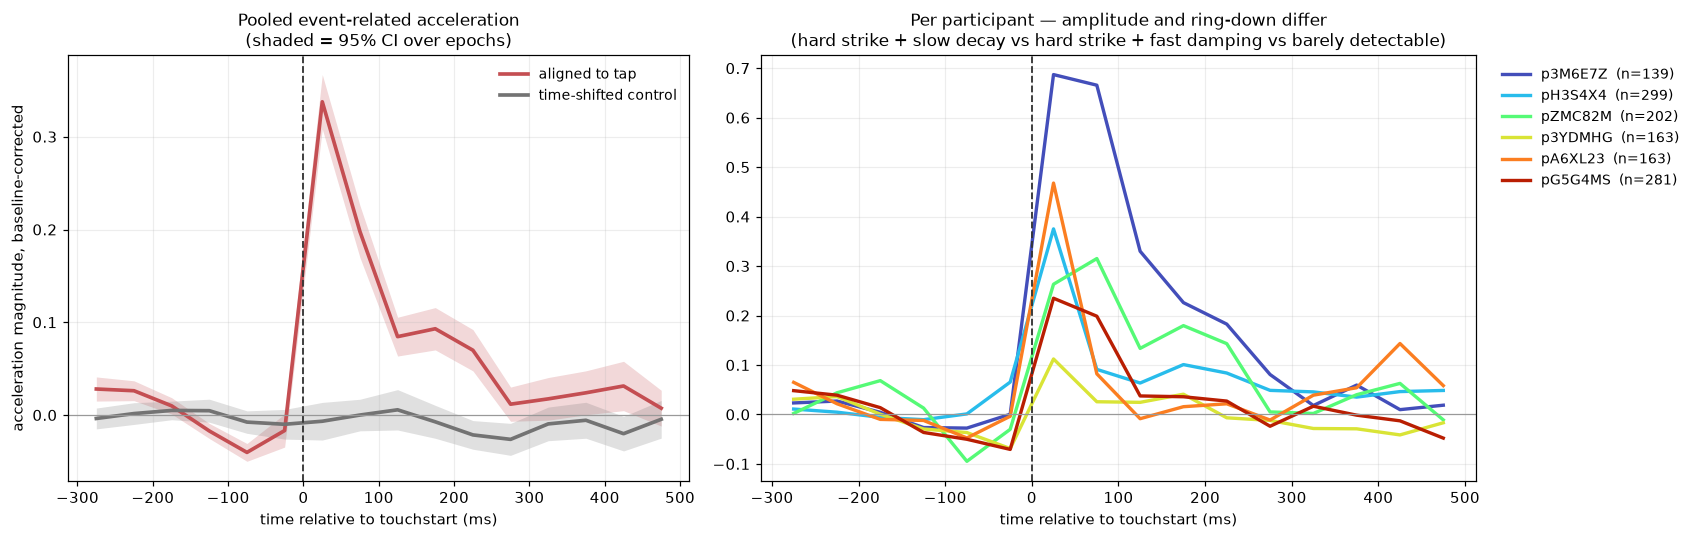

In [5]:
def plot_event_related(real, ctrl, meta):
    fig, axes = plt.subplots(1, 2, figsize=(15.5, 5), gridspec_kw={'width_ratios': [1, 1.15]})

    ax = axes[0]
    for arr, lab, c in ((real, 'aligned to tap', '#c44e52'), (ctrl, 'time-shifted control', '0.45')):
        m = np.nanmean(arr, axis=0)
        se = np.nanstd(arr, axis=0) / np.sqrt(np.sum(np.isfinite(arr), axis=0))
        ax.plot(BIN_MIDS, m, color=c, lw=2.4, label=lab)
        ax.fill_between(BIN_MIDS, m - 1.96 * se, m + 1.96 * se, color=c, alpha=0.22, lw=0)
    ax.axvline(0, color='0.2', ls='--', lw=1.2)
    ax.axhline(0, color='0.6', lw=0.8)
    ax.set_title("Pooled event-related acceleration\n(shaded = 95% CI over epochs)")
    ax.set_xlabel("time relative to touchstart (ms)")
    ax.set_ylabel("acceleration magnitude, baseline-corrected")
    ax.legend(frameon=False)

    ax = axes[1]
    for pid in PARTICIPANT_ORDER:
        m_ = meta['participantId'].to_numpy() == pid
        if m_.sum() < 20:
            continue
        ax.plot(BIN_MIDS, np.nanmean(real[m_], axis=0), color=pcolor(pid), lw=2.2,
                label=f"{pid}  (n={int(m_.sum())})")
    ax.axvline(0, color='0.2', ls='--', lw=1.2)
    ax.axhline(0, color='0.6', lw=0.8)
    ax.set_title("Per participant — amplitude and ring-down differ\n"
                 "(hard strike + slow decay vs hard strike + fast damping vs barely detectable)")
    ax.set_xlabel("time relative to touchstart (ms)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_event_related(era_real, era_ctrl, era_meta)

## 5. Per-tap impulse features

Five features per tap, each a different aspect of the same physical event:

| feature | what it means physically |
|---|---|
| `peak` | how hard the strike displaced the handset |
| `impulse_auc` | area under the response — total momentum transferred |
| `latency_ms` | delay from contact to peak displacement (sampling-limited, see Section 2) |
| `decay_ratio` | tail height relative to peak — **grip firmness**; a loosely held phone rings |
| `snr` | peak divided by that epoch's own pre-tap noise, an attempt at cancelling sensor scale |
| `z_share` | share of the response on the screen-normal axis — **strike geometry** |

`decay_ratio` and `z_share` are the two ratio features. The expectation going in was that
they would be the safest, since dividing one axis by the total cancels sensor gain in a
way an absolute amplitude cannot. **Section 7 only half-supports that** — `decay_ratio`
behaves as hoped, while `z_share` turns out to be almost perfectly correlated with pace
and loses most of its separability once pace is removed. Being scale-invariant protects
against the device confound; it does not protect against measuring the wrong thing.

In [6]:
def _area(y, x):
    fn = getattr(np, 'trapezoid', None) or np.trapz   # numpy >=2.0 renamed trapz
    return float(fn(y, x))


def tap_impulse_features(sess):
    arrs = motion_arrays(sess)
    if arrs is None:
        return pd.DataFrame()
    rows = []
    for t0 in np.sort(sess.loc[sess['kind'] == TAP_KIND, 'tRelMs'].to_numpy(float)):
        ep = epoch_at(arrs, t0)
        if ep is None:
            continue
        off, v, noise = ep
        post = (off >= RESPONSE_MS[0]) & (off <= RESPONSE_MS[1])
        po, pv = off[post], v[post]
        k = int(np.argmax(pv))
        peak = float(pv[k])
        if peak <= 0:          # no positive deflection: not an impulse
            continue
        tail = v[(off > TAIL_MS[0]) & (off <= TAIL_MS[1])]

        # per-axis peak, for the strike-geometry ratio
        ax_peaks = {}
        for c in ACCEL_COLS:
            e2 = epoch_at(arrs, t0, signal=arrs['comps'][c])
            if e2 is None:
                continue
            o2, v2, _ = e2
            p2 = (o2 >= RESPONSE_MS[0]) & (o2 <= RESPONSE_MS[1])
            ax_peaks[c] = float(np.abs(v2[p2]).max()) if p2.any() else np.nan
        tot = np.nansum(list(ax_peaks.values()))

        rows.append({
            't_rel_s': t0 / 1000.0,
            'peak': peak,
            'impulse_auc': _area(np.clip(pv, 0, None), po) / 1000.0,
            'latency_ms': float(po[k]),
            'decay_ratio': float(np.nanmean(tail) / peak) if len(tail) else np.nan,
            'snr': peak / noise if noise > 0 else np.nan,
            'z_share': (ax_peaks.get('payload_az', np.nan) / tot) if tot > 0 else np.nan,
            **{f"peak_{c.split('_')[-1]}": ax_peaks.get(c, np.nan) for c in ACCEL_COLS},
        })
    return pd.DataFrame(rows)


_frames = []
for sid, sess in raw.groupby('sessionId'):
    f = tap_impulse_features(sess)
    if f.empty:
        continue
    f['participantId'] = sess['participantId'].iloc[0]
    f['sessionId'] = sid
    _frames.append(f)
tap_features = pd.concat(_frames, ignore_index=True)

IMPULSE_FEATURES = ['peak', 'impulse_auc', 'latency_ms', 'decay_ratio', 'snr', 'z_share']
AMPLITUDE_LIKE = ['peak', 'impulse_auc', 'snr', 'peak_ax', 'peak_ay', 'peak_az']
RATIO_LIKE = ['decay_ratio', 'z_share']

print(f"{len(tap_features):,} taps with a measurable impulse\n")
tap_features.groupby('participantId')[IMPULSE_FEATURES].median().reindex(PARTICIPANT_ORDER).round(3)

1,165 taps with a measurable impulse



,peak,impulse_auc,latency_ms,decay_ratio,snr,z_share
participantId,,,,,,
p3M6E7Z,0.768,0.074,69.0,0.068,10.889,0.626
pH3S4X4,0.377,0.028,26.0,0.081,6.812,0.534
pZMC82M,0.524,0.048,105.0,-0.000,2.665,0.569
p3YDMHG,0.188,0.016,102.0,-0.045,3.027,0.503
pA6XL23,0.462,0.031,30.5,0.031,6.537,0.505
pG5G4MS,0.347,0.032,74.0,-0.026,2.947,0.451


## 6. Do the impulse features separate people?

Rank-based AUC over every participant pair: the probability that a randomly drawn value
from one exceeds one from the other, direction ignored. 0.5 is chance.

Reported at two levels. **Single tap** is the raw discriminability of one impact.
**Window** aggregates to P2's 7.5s CA window using the median of the taps inside it,
which is the number that matters operationally — and it requires at least two usable taps
in the window, which given Section 3's coverage is a real constraint rather than a
formality.

Watch `min` as much as `mean`. A feature with a high mean and a chance-level worst pair
is separating the easy people and doing nothing where it counts.

In [7]:
CA_WINDOW_S, CA_STRIDE_S = 7.5, 2.5
MIN_TAPS_PER_WINDOW = 2


def rank_auc(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if len(x) < 5 or len(y) < 5:
        return np.nan
    ranks = pd.Series(np.concatenate([x, y])).rank(method='average').to_numpy()
    return float((ranks[:len(x)].sum() - len(x) * (len(x) + 1) / 2) / (len(x) * len(y)))


def pairwise_scores(df, feature, parts=None):
    parts = PARTICIPANT_ORDER if parts is None else parts
    parts = [p for p in parts if p in set(df['participantId'])]
    vals = {p: df.loc[df['participantId'] == p, feature].to_numpy(float) for p in parts}
    out = {}
    for i, a in enumerate(parts):
        for b in parts[i + 1:]:
            v = rank_auc(vals[a], vals[b])
            if np.isfinite(v):
                out[(a, b)] = max(v, 1 - v)
    return out


def to_windows(df, window_s=CA_WINDOW_S, stride_s=CA_STRIDE_S, min_taps=MIN_TAPS_PER_WINDOW):
    '''Median impulse per CA window. n_taps doubles as the confidence term for fusion.'''
    rows = []
    for (pid, sid), g in df.groupby(['participantId', 'sessionId']):
        end = g['t_rel_s'].max()
        lo = 0.0
        while lo + window_s <= end + stride_s:
            m = (g['t_rel_s'] >= lo) & (g['t_rel_s'] < lo + window_s)
            if m.sum() >= min_taps:
                rec = {'participantId': pid, 'sessionId': sid, 'window_start_s': lo,
                       'n_taps': int(m.sum())}
                rec.update(g.loc[m, IMPULSE_FEATURES].median().to_dict())
                rows.append(rec)
            lo += stride_s
    return pd.DataFrame(rows)


impulse_windows = to_windows(tap_features)

_rows = []
for f in IMPULSE_FEATURES:
    s_tap = pairwise_scores(tap_features, f)
    s_win = pairwise_scores(impulse_windows, f)
    _rows.append({'feature': f,
                  'kind': 'ratio' if f in RATIO_LIKE else 'amplitude',
                  'tap_mean': np.mean(list(s_tap.values())) if s_tap else np.nan,
                  'tap_min': np.min(list(s_tap.values())) if s_tap else np.nan,
                  'win_mean': np.mean(list(s_win.values())) if s_win else np.nan,
                  'win_min': np.min(list(s_win.values())) if s_win else np.nan})
impulse_auc_table = (pd.DataFrame(_rows).sort_values('win_mean', ascending=False)
                     .reset_index(drop=True))

print(f"{len(impulse_windows):,} CA windows with >= {MIN_TAPS_PER_WINDOW} usable taps "
      f"({impulse_windows['n_taps'].median():.0f} taps in the median window)\n")
impulse_auc_table.round(3)

911 CA windows with >= 2 usable taps (3 taps in the median window)



,feature,kind,tap_mean,tap_min,win_mean,win_min
0,impulse_auc,amplitude,0.662,0.503,0.734,0.509
1,peak,amplitude,0.663,0.505,0.726,0.525
2,snr,amplitude,0.660,0.501,0.713,0.501
3,z_share,ratio,0.622,0.520,0.664,0.525
4,latency_ms,amplitude,0.608,0.520,0.632,0.528
5,decay_ratio,ratio,0.565,0.506,0.630,0.535


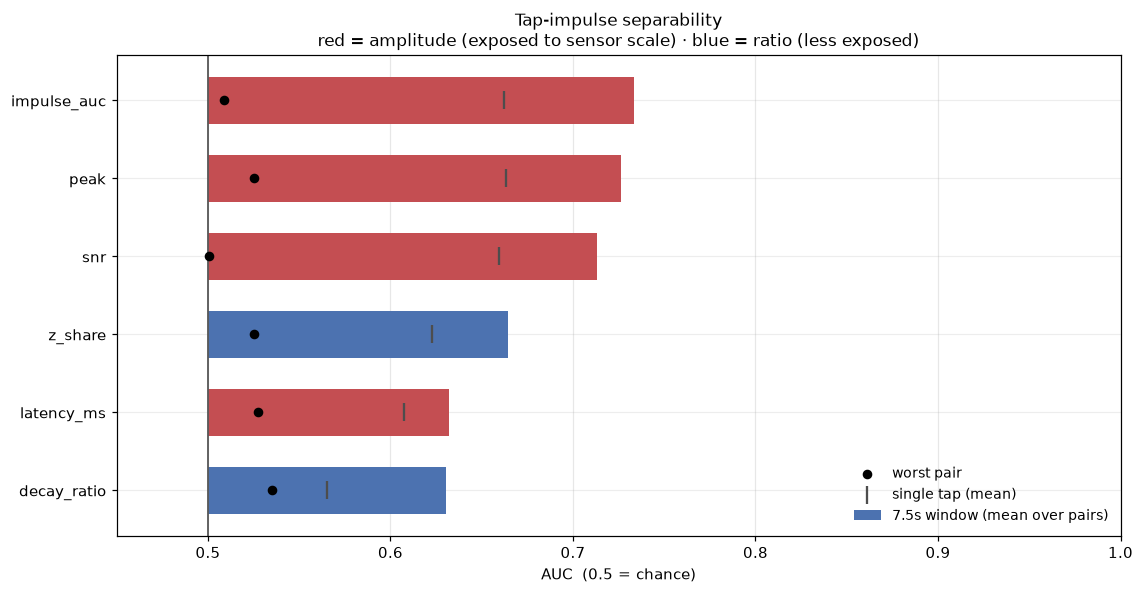

In [8]:
def plot_impulse_auc(table):
    d = table.dropna(subset=['win_mean']).sort_values('win_mean')
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(10.5, 0.55 * len(d) + 2.2))
    colors = ['#4c72b0' if k == 'ratio' else '#c44e52' for k in d['kind']]
    ax.barh(y, d['win_mean'] - 0.5, left=0.5, color=colors, height=0.6,
            label=f'{CA_WINDOW_S}s window (mean over pairs)')
    ax.scatter(d['win_min'], y, color='black', s=28, zorder=3, label='worst pair')
    ax.scatter(d['tap_mean'], y, marker='|', color='0.3', s=140, zorder=3, label='single tap (mean)')
    ax.axvline(0.5, color='0.35', lw=1.2)
    ax.set_yticks(y); ax.set_yticklabels(d['feature'])
    ax.set_xlim(0.45, 1.0)
    ax.set_xlabel("AUC  (0.5 = chance)")
    ax.set_title("Tap-impulse separability\nred = amplitude (exposed to sensor scale) · "
                 "blue = ratio (less exposed)")
    ax.legend(loc='lower right', frameon=False)
    ax.grid(True, axis='x', alpha=0.3); ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_impulse_auc(impulse_auc_table)

## 7. Is it just measuring pace again?

Notebook 04 found that ranking features by how well they separate the fastest and slowest
participants systematically rewards anything correlated with pace. A feature that only
re-expresses pace adds nothing to a model that already has `press_to_press`.

Two tests. First, the correlation between each feature's participant median and that
participant's median session duration. Second — and more informative — the **partial**
separability: regress the feature on session duration across participants, then re-run
the pairwise AUC on the residuals. A feature that keeps its AUC after pace is removed is
carrying something new.

In [9]:
def pace_correlation(df, feature, sessions_meta):
    per = df.groupby('participantId')[feature].median()
    dur = sessions_meta.groupby('participantId')['duration_s'].median()
    common = per.index.intersection(dur.index)
    if len(common) < 3:
        return np.nan
    return float(np.corrcoef(dur[common], per[common])[0, 1])


def residualise_on_pace(df, feature, sessions_meta):
    '''Remove the linear pace component at participant level, keeping within-participant
    spread intact so the AUC still has something to work with.'''
    dur = sessions_meta.groupby('participantId')['duration_s'].median()
    d = df[['participantId', feature]].dropna().copy()
    d['pace'] = d['participantId'].map(dur)
    d = d.dropna(subset=['pace'])
    if d['participantId'].nunique() < 3:
        return d.assign(resid=d[feature])
    per = d.groupby('participantId').agg(v=(feature, 'median'), pace=('pace', 'first'))
    slope, intercept = np.polyfit(per['pace'], per['v'], 1)
    d['resid'] = d[feature] - (intercept + slope * d['pace'])
    return d


_rows = []
for f in IMPULSE_FEATURES:
    raw_scores = pairwise_scores(impulse_windows, f)
    res = residualise_on_pace(impulse_windows, f, session_index)
    res_scores = pairwise_scores(res.rename(columns={'resid': f'{f}_r'}), f'{f}_r')
    _rows.append({'feature': f,
                  'kind': 'ratio' if f in RATIO_LIKE else 'amplitude',
                  'r_with_pace': pace_correlation(impulse_windows, f, session_index),
                  'auc_raw': np.mean(list(raw_scores.values())) if raw_scores else np.nan,
                  'auc_pace_removed': np.mean(list(res_scores.values())) if res_scores else np.nan})
pace_table = pd.DataFrame(_rows)
pace_table['retained'] = (pace_table['auc_pace_removed'] - 0.5) / (pace_table['auc_raw'] - 0.5)
pace_table = pace_table.sort_values('auc_pace_removed', ascending=False).reset_index(drop=True)

print("'retained' = share of above-chance separability surviving after pace is regressed out.")
print("Near 1.0 means the feature was never about pace; near 0 means it was only pace.\n")
pace_table.round(3)

'retained' = share of above-chance separability surviving after pace is regressed out.
Near 1.0 means the feature was never about pace; near 0 means it was only pace.



,feature,kind,r_with_pace,auc_raw,auc_pace_removed,retained
0,impulse_auc,amplitude,0.786,0.734,0.683,0.784
1,peak,amplitude,0.669,0.726,0.664,0.727
2,snr,amplitude,0.796,0.713,0.644,0.676
3,latency_ms,amplitude,-0.086,0.632,0.631,0.991
4,decay_ratio,ratio,0.503,0.630,0.610,0.846
5,z_share,ratio,0.950,0.664,0.562,0.378


## 8. Is it just measuring the handset?

This is the sharpest confound in the project. Accelerometer sensitivity, handset mass and
case damping all scale the measured amplitude directly, and every participant is on their
own device — so a high AUC on an amplitude feature is exactly what a pure device
fingerprint would also produce.

Nothing here resolves that; only multi-user-per-device data can. What this section does is
narrow it, using the artifact signature that worked in earlier analysis: **a device
constant reproduces across a person's own sessions essentially exactly, because hardware
does not vary**. Behaviour does. So a feature whose within-participant across-session
variance is near zero relative to its between-participant spread should be treated as a
handset property until proven otherwise.

`snr` normalises each impulse by its own epoch's noise floor, which was an attempt to
divide out sensor gain. Whether that helped is reported rather than assumed.

In [10]:
def artifact_signature(df, feature, min_sessions=2):
    per = df.groupby(['participantId', 'sessionId'])[feature].median().reset_index()
    rep = per.groupby('participantId').filter(lambda g: len(g) >= min_sessions)
    if rep['participantId'].nunique() < 2:
        return {'feature': feature, 'within_sd': np.nan, 'between_sd': np.nan,
                'icc': np.nan, 'n_repeat_participants': rep['participantId'].nunique()}
    means = rep.groupby('participantId')[feature].mean()
    between = float(np.var(means.to_numpy(), ddof=1))
    within_each = [np.var(g[feature].to_numpy(), ddof=1)
                   for _, g in rep.groupby('participantId') if len(g) > 1]
    within = float(np.mean(within_each)) if within_each else np.nan
    icc = between / (between + within) if np.isfinite(within) and (between + within) > 0 else np.nan
    return {'feature': feature, 'within_sd': np.sqrt(within) if np.isfinite(within) else np.nan,
            'between_sd': np.sqrt(between), 'icc': icc,
            'n_repeat_participants': rep['participantId'].nunique()}


artifact_table = pd.DataFrame([artifact_signature(tap_features, f) for f in IMPULSE_FEATURES])
artifact_table['kind'] = np.where(artifact_table['feature'].isin(RATIO_LIKE), 'ratio', 'amplitude')
artifact_table['flag'] = np.where(
    artifact_table['icc'] > 0.999, 'SUSPECT: reproduces exactly across sessions',
    np.where(artifact_table['icc'] < 0.3, 'unstable: state rather than trait', 'behavioural range'))

print("ICC ~1.0 with near-zero within-person variance is the device-constant signature.")
print("Behavioural features vary between a person's own sessions; hardware does not.\n")
print(artifact_table.round(3).to_string(index=False))

print("\nSession-to-session reproducibility, participants with repeat sessions:")
for f in ['peak', 'z_share']:
    per = tap_features.groupby(['participantId', 'sessionId'])[f].median()
    print(f"\n  {f}:")
    for pid, g in per.groupby(level=0):
        if len(g) > 1:
            print(f"    {pid:10s} {[round(float(v), 3) for v in g.to_numpy()]}")

ICC ~1.0 with near-zero within-person variance is the device-constant signature.
Behavioural features vary between a person's own sessions; hardware does not.

    feature  within_sd  between_sd   icc  n_repeat_participants      kind              flag
       peak      0.040       0.112 0.888                      4 amplitude behavioural range
impulse_auc      0.004       0.007 0.715                      4 amplitude behavioural range
 latency_ms      8.101      37.930 0.956                      4 amplitude behavioural range
decay_ratio      0.035       0.059 0.737                      4     ratio behavioural range
        snr      0.914       2.239 0.857                      4 amplitude behavioural range
    z_share      0.025       0.032 0.618                      4     ratio behavioural range

Session-to-session reproducibility, participants with repeat sessions:

  peak:
    p3YDMHG    [0.211, 0.171]
    pA6XL23    [0.425, 0.493]
    pG5G4MS    [0.294, 0.392, 0.368, 0.336]
    pH3S4X4

## 9. Which axis carries it

If the impulse is genuinely a finger strike, the response should concentrate on the axis
perpendicular to the screen — that is the direction the finger pushes. If instead it were
spread evenly, or dominated by an in-plane axis, that would suggest we are picking up
hand-wobble correlated with tapping rather than the strike itself.

This is a physics check on whether the measurement means what the notebook claims, and it
is worth running again on any new device cohort.

Dominant axis per participant:
participantId
p3M6E7Z    peak_az
p3YDMHG    peak_az
pA6XL23    peak_az
pG5G4MS    peak_az
pH3S4X4    peak_az
pZMC82M    peak_az

Screen-normal dominant for 6/6 participants.


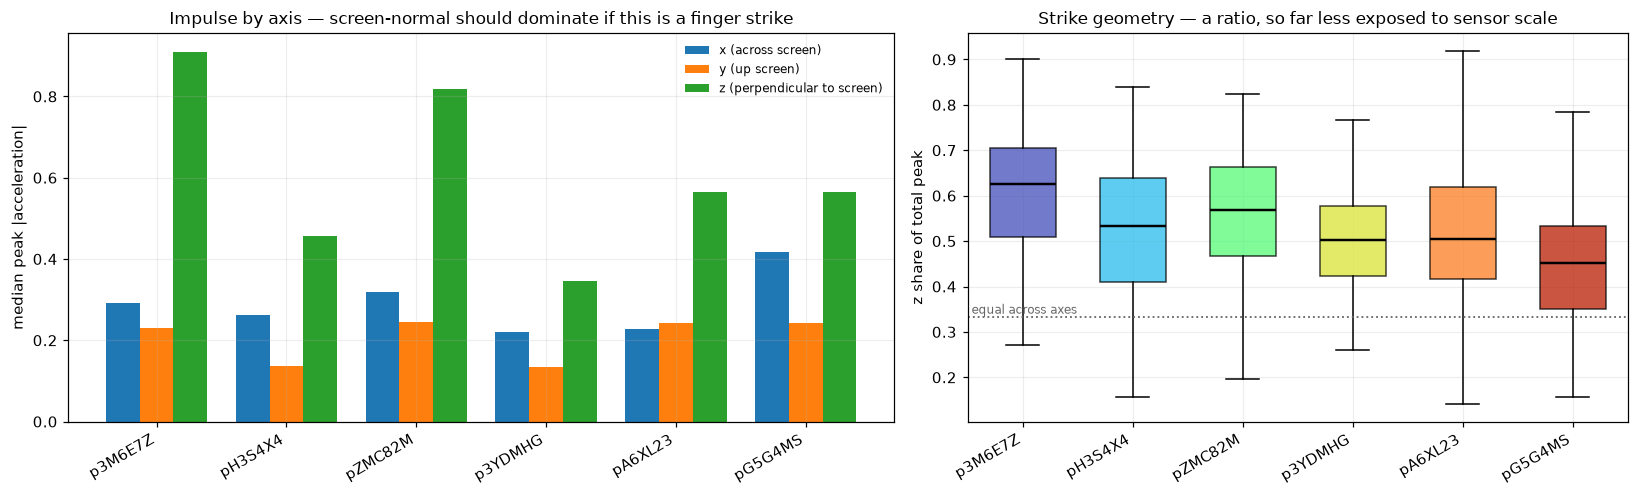

In [11]:
def plot_axis_decomposition(df):
    cols = [f"peak_{c.split('_')[-1]}" for c in ACCEL_COLS]
    med = df.groupby('participantId')[cols].median().reindex(PARTICIPANT_ORDER).dropna(how='all')

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.25, 1]})
    ax = axes[0]
    x = np.arange(len(med)); w = 0.26
    for i, (c, lab) in enumerate(zip(cols, [AXIS_NAMES[c] for c in ACCEL_COLS])):
        ax.bar(x + (i - 1) * w, med[c], width=w, label=lab)
    ax.set_xticks(x); ax.set_xticklabels(med.index, rotation=30, ha='right')
    ax.set_ylabel("median peak |acceleration|")
    ax.set_title("Impulse by axis — screen-normal should dominate if this is a finger strike")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    data, labels, colors = [], [], []
    for pid in PARTICIPANT_ORDER:
        v = df.loc[df['participantId'] == pid, 'z_share'].dropna().to_numpy()
        if len(v) < 5:
            continue
        data.append(v); labels.append(pid); colors.append(pcolor(pid))
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6,
                    medianprops={'color': 'black', 'lw': 1.6})
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.axhline(1 / 3, color='0.4', ls=':', lw=1.2)
    ax.text(0.5, 1 / 3, ' equal across axes', fontsize=8, color='0.4', va='bottom')
    ax.set_ylabel("z share of total peak")
    ax.set_title("Strike geometry — a ratio, so far less exposed to sensor scale")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


_dom = (tap_features.groupby('participantId')[[f"peak_{c.split('_')[-1]}" for c in ACCEL_COLS]]
        .median().idxmax(axis=1))
print("Dominant axis per participant:")
print(_dom.to_string())
print(f"\nScreen-normal dominant for {(_dom == 'peak_az').sum()}/{len(_dom)} participants.")
plot_axis_decomposition(tap_features)

## 10. Verdict and export

The verdict rule below is deliberately mechanical so it can be re-run on new data without
re-arguing the case each time. A feature is **included** if it separates people at window
level, keeps most of that separability once pace is removed, and does not carry the
device-constant signature. It is **held** if it separates but is either mostly pace or
sampling-limited, and **excluded** otherwise.

Two of its calls are worth reading closely because they run against intuition.
`z_share` looks like the safest feature in the set — a scale-invariant ratio with the best
worst-pair score — and the rule still holds it, because Section 7 shows it is almost
entirely pace. `latency_ms` looks like the weakest, and it is the *only* feature here
essentially uncorrelated with pace, so it is held for a fixable reason (sampling rate)
rather than dismissed. If the motion rate is ever raised, that is the one to re-test
first.

In [12]:
WIN_MEAN_MIN, RETAINED_MIN, ICC_SUSPECT = 0.60, 0.60, 0.999

verdict = (impulse_auc_table.merge(pace_table[['feature', 'r_with_pace', 'auc_pace_removed', 'retained']],
                                   on='feature')
           .merge(artifact_table[['feature', 'icc', 'flag']], on='feature'))


def decide(r):
    if np.isfinite(r['icc']) and r['icc'] > ICC_SUSPECT:
        return 'EXCLUDE', 'reproduces across sessions like a device constant'
    if not np.isfinite(r['win_mean']) or r['win_mean'] < WIN_MEAN_MIN:
        return 'EXCLUDE', 'does not separate at window level'
    if r['feature'] == 'latency_ms':
        return 'HOLD', f'sampling-limited at {SAMPLE_HZ:.0f} Hz; revisit if the rate is raised'
    if np.isfinite(r['retained']) and r['retained'] < RETAINED_MIN:
        return 'HOLD', 'largely re-expresses pace; little added over the timing features'
    if r['kind'] == 'amplitude':
        return 'INCLUDE', 'separates and survives pace; amplitude, so recheck once devices are shared'
    return 'INCLUDE', 'separates and survives pace; ratio feature, less exposed to sensor scale'


verdict[['decision', 'reason']] = verdict.apply(lambda r: pd.Series(decide(r)), axis=1)
verdict = verdict.sort_values(['decision', 'win_mean'], ascending=[True, False]).reset_index(drop=True)

for d in ['INCLUDE', 'HOLD', 'EXCLUDE']:
    sub = verdict.loc[verdict['decision'] == d]
    if sub.empty:
        continue
    print(f"{d}:")
    for r in sub.itertuples():
        print(f"   {r.feature:14s} win AUC {r.win_mean:.3f}  pace r {r.r_with_pace:+.2f}  -> {r.reason}")
    print()
verdict[['feature', 'kind', 'decision', 'win_mean', 'win_min', 'r_with_pace',
         'auc_pace_removed', 'retained', 'icc', 'reason']].round(3)

INCLUDE:
   impulse_auc    win AUC 0.734  pace r +0.79  -> separates and survives pace; amplitude, so recheck once devices are shared
   peak           win AUC 0.726  pace r +0.67  -> separates and survives pace; amplitude, so recheck once devices are shared
   snr            win AUC 0.713  pace r +0.80  -> separates and survives pace; amplitude, so recheck once devices are shared
   decay_ratio    win AUC 0.630  pace r +0.50  -> separates and survives pace; ratio feature, less exposed to sensor scale

HOLD:
   z_share        win AUC 0.664  pace r +0.95  -> largely re-expresses pace; little added over the timing features
   latency_ms     win AUC 0.632  pace r -0.09  -> sampling-limited at 20 Hz; revisit if the rate is raised



,feature,kind,decision,win_mean,win_min,r_with_pace,auc_pace_removed,retained,icc,reason
0,z_share,ratio,HOLD,0.664,0.525,0.950,0.562,0.378,0.618,largely re-expresses pace; little added over t...
1,latency_ms,amplitude,HOLD,0.632,0.528,-0.086,0.631,0.991,0.956,sampling-limited at 20 Hz; revisit if the rate...
2,impulse_auc,amplitude,INCLUDE,0.734,0.509,0.786,0.683,0.784,0.715,"separates and survives pace; amplitude, so rec..."
3,peak,amplitude,INCLUDE,0.726,0.525,0.669,0.664,0.727,0.888,"separates and survives pace; amplitude, so rec..."
4,snr,amplitude,INCLUDE,0.713,0.501,0.796,0.644,0.676,0.857,"separates and survives pace; amplitude, so rec..."
5,decay_ratio,ratio,INCLUDE,0.630,0.535,0.503,0.610,0.846,0.737,"separates and survives pace; ratio feature, le..."


In [13]:
OUT_DIR = Path("../../data/interim")
OUT_DIR.mkdir(parents=True, exist_ok=True)

_exports = {
    'tapmotion_tap_features.csv': tap_features,
    'tapmotion_windows.csv': impulse_windows,
    'tapmotion_separability.csv': impulse_auc_table,
    'tapmotion_pace_check.csv': pace_table,
    'tapmotion_artifact_check.csv': artifact_table,
    'tapmotion_verdict.csv': verdict,
    'tapmotion_coverage.csv': tap_coverage,
}
for name, frame in _exports.items():
    frame.to_csv(OUT_DIR / name, index=False)
    print(f"wrote {OUT_DIR / name}  ({len(frame):,} rows)")

wrote ../../data/interim/tapmotion_tap_features.csv  (1,165 rows)
wrote ../../data/interim/tapmotion_windows.csv  (911 rows)
wrote ../../data/interim/tapmotion_separability.csv  (6 rows)
wrote ../../data/interim/tapmotion_pace_check.csv  (6 rows)
wrote ../../data/interim/tapmotion_artifact_check.csv  (6 rows)
wrote ../../data/interim/tapmotion_verdict.csv  (6 rows)
wrote ../../data/interim/tapmotion_coverage.csv  (13 rows)


## 11. What to do with this

**For `build_windows_dataset.py`.** Compute the impulse features per tap and aggregate to
the window median, carrying `n_taps` alongside them. That count is not bookkeeping — given
the coverage in Section 3 it is the natural confidence term for the fusion stage, and a
window with no usable taps should contribute zero weight rather than an imputed score.

**Treat this as its own modality.** It is not a touch feature and not a motion feature; it
is the coupling of the two, and it fails independently of both. Motion dropout kills it
while leaving touch timing intact, so it belongs in the fusion as a separate stream with
its own availability gate.

**The honest position on the device confound.** The amplitude features are the strongest
here and also the most exposed — a handset with a more sensitive accelerometer will read
as a harder tapper, and nothing in this notebook can distinguish those. `snr` was an
attempt to cancel sensor gain and Section 7 reports whether it worked. The ratio features
(`z_share`, `decay_ratio`) are structurally safer because a ratio divides the scale out,
which is why they are worth keeping even where their raw AUC is lower. When the
multi-user-per-device data arrives, the test is direct: two people on one handset should
still separate on these features, and if they do not, the amplitudes were device all along.

**The sampling rate is the cheapest available win.** At the observed rate the impulse is
two or three samples and `latency_ms` is mostly quantisation. If `logger.js` can raise
`devicemotion` during tap-adjacent periods, peak, latency and decay should all sharpen
together — and unlike most improvements here, that one does not need more participants.

**Worth a literature check before writing up.** Tap-induced handset motion is not a new
idea in behavioural biometrics, and the established feature definitions and reported
effect sizes would be a better anchor for the dissertation than a set invented here.
